In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model
from scipy import stats
from matplotlib.ticker import ScalarFormatter


pd.options.display.max_rows=30
print(pd.options.display.max_rows)

30


In [2]:
data=np.arange(1,13).astype(str)
errordata=np.char.add('E',data.astype(str))
print(errordata)


['E1' 'E2' 'E3' 'E4' 'E5' 'E6' 'E7' 'E8' 'E9' 'E10' 'E11' 'E12']


In [3]:
df=pd.read_csv("ewdata.csv")
#df.info()
df.iloc[:,1]
df["E5"]
#df['E5'].to_numpy(dtype=float)

0     0.211181
1          NaN
2          NaN
3          NaN
4     0.097232
5          NaN
6          NaN
7     0.146916
8     0.109492
9     0.039583
10         NaN
11         NaN
12         NaN
13    0.220740
14         NaN
15         NaN
16         NaN
17    0.158729
18         NaN
19    0.200421
20         NaN
21         NaN
22         NaN
23    0.154005
24         NaN
Name: E5, dtype: float64

3176993521627.7524
1969601029627.226
5802692014125.026
2076865818862.648
231896581990.93097
564877111506.0637
941678860432.8
717624803312.4705
404568768541.3903
2207165931317.3477
39806097572138.984
3331580257208.969
3889083073291.969
1715852829744.2014
9467744846915.543
4976214558889.969
71293768831789.83
828394477777.1952
270574738553.14728
153599199643.92654
668296936527.9916
3165585923576.8086
236997449807.61816
679072463992.1892


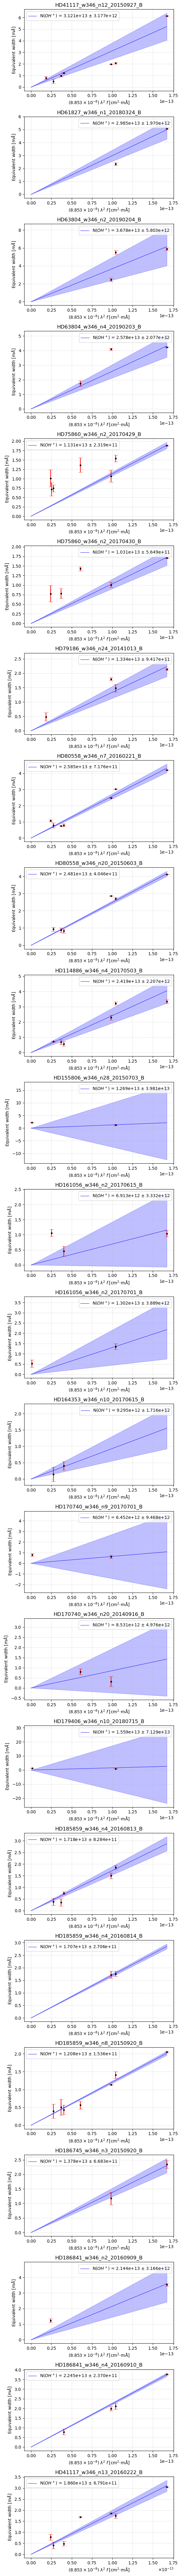

In [28]:
size=24
data_array=df[data].to_numpy()
error_array=df[errordata].to_numpy()
id=df.iloc[:,1].to_numpy()
lamb = np.array([3583.75574, 3572.65187, 3566.4458, 3565.34592,
                 3559.8062, 3552.325, 3346.95559, 3337.3570, 3332.177, 3330.409,3326.369, 3319.967])
f = 1 * np.array([5.27, 3.12, 1.17, 1.28, 0.87, 0.05, 3.52, 2.06, 0.82, 0.85, 0.62, 0.04]) * (8.853 * (10 ** -18))



fig,ax=plt.subplots(size,1,figsize=(6,3.5*size))
scale = 1e13
x=lamb*f
x_scaled = x * scale

for n in range (size):

    y=data_array[n]
    def linear(x, m, b):
        return m * x + b
    
    model = Model(linear)
    params = model.make_params(m=1.0, b=0.0)
    params['b'].vary = False  # keep intercept fixed at 0
    
    # --- Choose error mode ---
    use_relative_errors = False   # set True if you want relative (% of YY)
    
    if use_relative_errors:
        rel_percent = 0.05  # 5% relative error
        errors = rel_percent * y  # convert to absolute
    else:
        # Absolute errors
        errors = error_array[n]
    weights=1/errors
    
    
    # --- Fit the model ---
    result = model.fit(y, params, x=x_scaled, weights=weights,nan_policy='omit')
    #print(result.fit_report())
    
    # --- Extract slope and uncertainty ---
    m_scaled = result.params['m'].value
    m_fit = m_scaled * scale  # convert slope back to original x-units
    
    # Estimate variance of slope
    if result.covar is not None:
        var_m_scaled = result.covar[0, 0]
    else:
        residuals = y - m_scaled * x_scaled
        dof = len(x_scaled) - 1
        sigma2 = np.sum(residuals ** 2) / dof
        var_m_scaled = sigma2 / np.sum(x_scaled ** 2)
    
    var_m = (scale ** 2) * var_m_scaled
    std_m = np.sqrt(var_m)
    
    # --- Confidence band (95%) ---
    x_sorted = np.linspace(0, np.max(x), 200)  # ensure intercept is visible at (0,0)
    y_fit_sorted = m_fit * x_sorted
    std_pred = np.sqrt((x_sorted ** 2) * var_m)
    t_val = stats.t.ppf(0.975, len(x) - 1)  # 95% confidence
    delta = t_val * std_pred
    
    # --- Plot with error bars ---

    ax[n].errorbar(x, y, yerr=errors, fmt='o', capsize=5, capthick=0.5,
                 ecolor='red', color='black', markersize=3)
    ax[n].plot(x_sorted, y_fit_sorted, color='blue',
             label=rf"N($OH^+$) = {m_fit:.3e} $\pm$ {std_m:.3e}",linewidth=0.7)
    ax[n].fill_between(x_sorted, y_fit_sorted - delta, y_fit_sorted + delta,
                     alpha=0.25, color='blue')
    
    # --- Labeling & formatting ---
    ax[n].set_xlabel(r"$(8.853 \times 10^{-8})\;\lambda^2\; f\; [\mathrm{cm}^2\!\cdot\!\mathrm{m\AA}]$")
    ax[n].set_ylabel(r'Equivalent width [m$\AA$]')
    ax[n].set_title(f"{id[n]}")
    ax[n].legend()
    ax[n].grid(True, alpha=0.3)
    
    # --- Format X-axis in scientific notation ---
    ax[n] = plt.gca()
    ax[n].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[n].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
    print(f"{std_m}")
    fig.tight_layout()
    #ax[n].show()

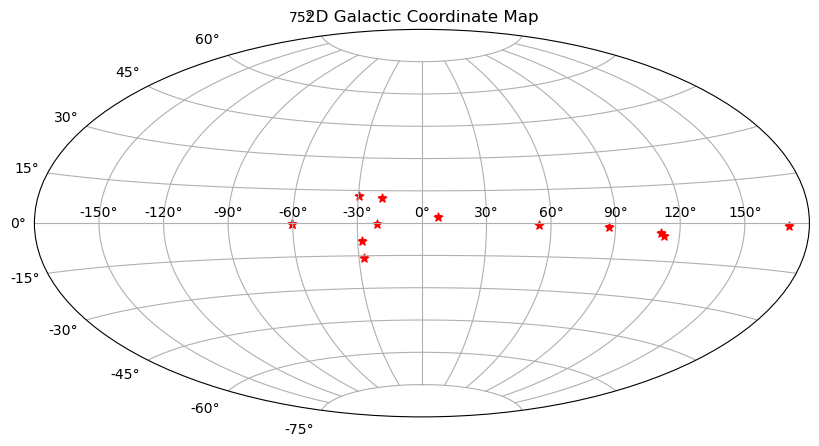

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your data

l = np.array([189.6917597771835,273.0736790442365,247.1214876053018,248.7666613255003 ,305.52053645,352.5858331154443,018.6701844711387,029.7252288510154,021.0573870310438,
             028.2285141129100,027.8231175063679,060.2168670967526,060.4065242051227   ])   # galactic longitude
b = np.array([-00.8604420580600,-1.4663521535318,-05.0699274800640,-03.7101969711584,-00.82648871,02.8683182058143,11.5807966422993,12.6325173791488,-00.5259148411975,
             -08.3118146155454,-16.0369902214863,-00.2707186859153,-00.2918284361452   ])  # galactic latitude
# Convert degrees to radians
l_rad = np.radians(l)
b_rad = np.radians(b)

# Shift longitude so 0° is at the center
l_rad = np.remainder(l_rad + 2*np.pi, 2*np.pi)
l_rad[l_rad > np.pi] -= 2*np.pi
l_rad = -l_rad

# Create Aitoff projection
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="aitoff")

ax.scatter(l_rad, b_rad, s=40, color="red",marker='*')

ax.set_title("2D Galactic Coordinate Map")
ax.grid(True)

plt.show()